<a href="https://colab.research.google.com/github/muhammadhasbiashiddiqi/PCVK_Genap_2026/blob/main/Week5_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

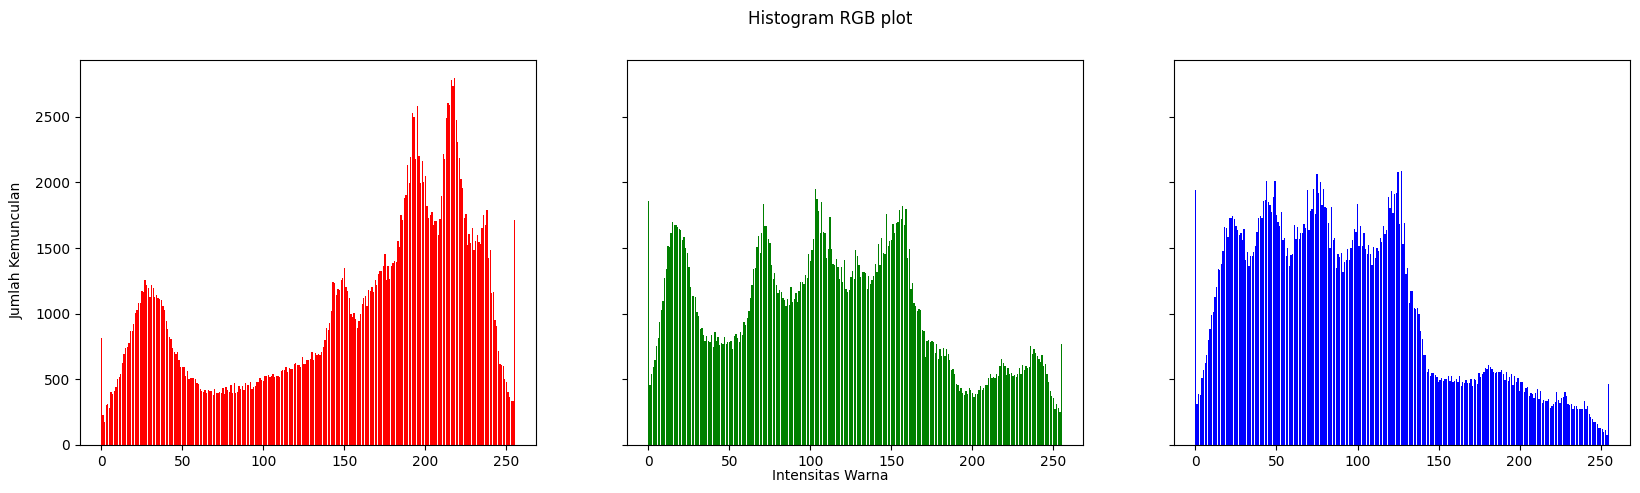

In [8]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Gambar/Lena.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

In [11]:
import os
import cv2 as cv
import numpy as np
CONTOH = '/content/drive/MyDrive/PCVK/Gambar'
BASE = '/content/drive/MyDrive/PCVK/Gambar'

def verifikasi_histogram(img_path):
  gray = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

  if gray is None:
    print(f'Gagal membaca citra dari path: {img_path}')
    return
  h_manual = np.zeros(256, dtype=np.int64)
  for y in range(gray.shape[0]):
    for x in range(gray.shape[1]):
      h_manual[gray[y, x]] += 1
  h_numpy, _ = np.histogram(gray.ravel(), bins=256, range=(0, 256))
  h_cv = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten()
  diff_manual_np = np.max(np.abs(h_manual - h_numpy))
  diff_manual_cv = np.max(np.abs(h_manual - h_cv))
  diff_np_cv = np.max(np.abs(h_numpy - h_cv))

  # hasil
  print(f'=== VERIFIKASI HISTOGRAM: {os.path.basename(img_path)} ===')
  print(f'Selisih Maksimum Manual vs NumPy  : {diff_manual_np}')
  print(f'Selisih Maksimum Manual vs OpenCV : {diff_manual_cv}')
  print(f'Selisih Maksimum NumPy vs OpenCV  : {diff_np_cv}')

  if diff_manual_np == 0 and diff_manual_cv == 0 and diff_np_cv == 0:
    print('STATUS: HASIL SAMA PERSIS (Selisih = 0)\n')
  else:
    print('STATUS: TERDAPAT PERBEDAAN\n')


# lena
verifikasi_histogram(CONTOH + '/Lena.jpeg')

# ktm
verifikasi_histogram(BASE + '/ktm.png')

=== VERIFIKASI HISTOGRAM: Lena.jpeg ===
Selisih Maksimum Manual vs NumPy  : 0
Selisih Maksimum Manual vs OpenCV : 0.0
Selisih Maksimum NumPy vs OpenCV  : 0.0
STATUS: HASIL SAMA PERSIS (Selisih = 0)

=== VERIFIKASI HISTOGRAM: ktm.png ===
Selisih Maksimum Manual vs NumPy  : 0
Selisih Maksimum Manual vs OpenCV : 0.0
Selisih Maksimum NumPy vs OpenCV  : 0.0
STATUS: HASIL SAMA PERSIS (Selisih = 0)



Gagal membaca citra dari path: /content/drive/MyDrive/PCVK/Gambar/KTM1a.jpg. Pastikan file ada dan path benar.
Gagal membaca citra dari path: /content/drive/MyDrive/PCVK/Gambar/KTM1b.jpg. Pastikan file ada dan path benar.
Gagal membaca citra dari path: /content/drive/MyDrive/PCVK/Gambar/KTM1c.jpg. Pastikan file ada dan path benar.
Gagal membaca citra dari path: /content/drive/MyDrive/PCVK/Gambar/KTM1d.jpg. Pastikan file ada dan path benar.


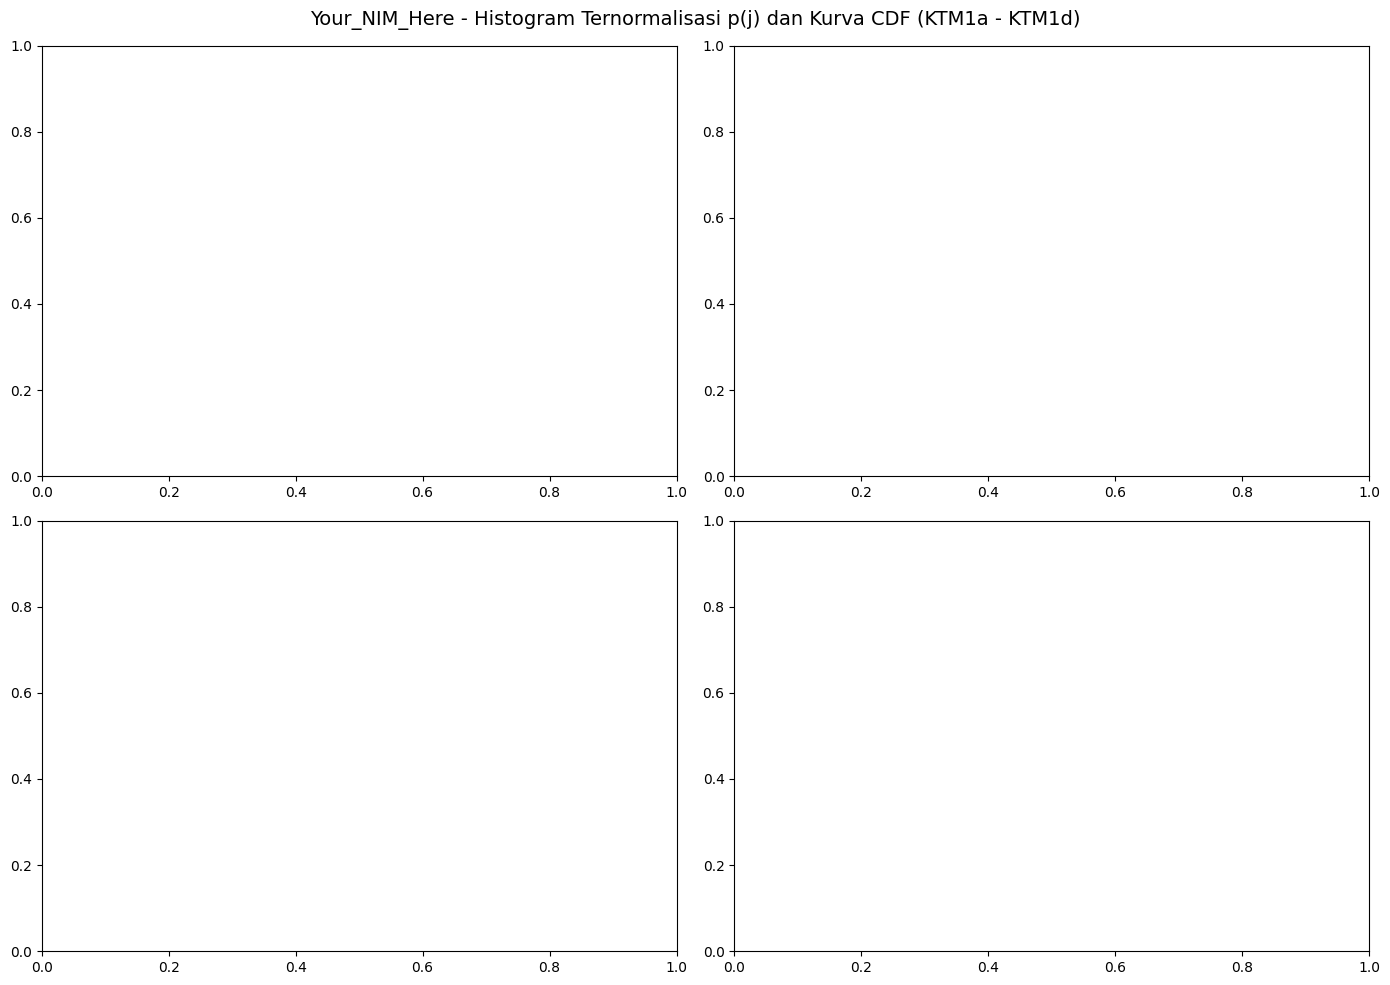

In [19]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
NIM = 'Your_NIM_Here'
ktm_files = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'{NIM} - Histogram Ternormalisasi p(j) dan Kurva CDF (KTM1a - KTM1d)',
    fontsize=14,
)
for idx, fname in enumerate(ktm_files):
  row, col = idx // 2, idx % 2
  img_path = BASE + '/' + fname
  gray = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

  if gray is None:
    print(f'Gagal membaca citra dari path: {img_path}. Pastikan file ada dan path benar.')
    continue
  h, _ = np.histogram(gray.ravel(), bins=256, range=(0, 256))
  p = h / gray.size
  cdf = np.cumsum(p)

  ax = axs[row, col]
  ax.bar(
      range(256),
      p,
      color='gray',
      alpha=0.6,
      width=1.0,
      label='p(j) Normalisasi',
  )
  ax.set_title(f'{NIM} - {fname}', fontsize=11)
  ax.set_xlabel('Intensitas Piksel (0 - 255)')
  ax.set_ylabel('Probabilitas p(j)', color='black')
  ax.set_xlim([0, 255])
  ax2 = ax.twinx()
  ax2.plot(range(256), cdf, color='red', linewidth=2, label='CDF')
  ax2.set_ylabel('Kumulatif CDF', color='red')
  ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()